In [1]:
!pip install -q xgboost shap pmdarima joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 25.2 MB/s eta 0:00:00


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import xgboost as xgb
import shap
import joblib
import pmdarima as pm

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Bidirectional, Dense, Dropout,
                                     Input, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "font.size":        11,
})

print("✓ All imports successful.")
print(f"  TensorFlow : {tf.__version__}")
print(f"  GPU        : {tf.config.list_physical_devices('GPU')}")


✓ All imports successful.
  TensorFlow : 2.19.0
  GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = "/content/drive/MyDrive/5G_Traffic_Datasets"

Mounted at /content/drive


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 │ Load Dataset                                              ║
# ╚══════════════════════════════════════════════════════════════════════╝

import os
import pandas as pd
import numpy as np

# ── Paths ─────────────────────────────────────────────────────────────
BASE_PATH = "/content/5G_data/5G_Traffic_Datasets"   # ← one level up from Live_Streaming
SAVE_DIR  = "/content/drive/MyDrive/5G_Project_Results"
os.makedirs(SAVE_DIR, exist_ok=True)

print("📂 Categories found in dataset:")
for item in sorted(os.listdir(BASE_PATH)):
    full = os.path.join(BASE_PATH, item)
    if os.path.isdir(full):
        sub_csvs = []
        for r, d, files in os.walk(full):
            sub_csvs += [f for f in files if f.endswith(".csv")]
        print(f"   📁 {item}  →  {len(sub_csvs)} CSV files")

# ── Column names we want (drop garbage Korean columns) ────────────────
KEEP_COLS = ["No.", "Time", "Source", "Destination", "Protocol", "Length", "Info"]

def load_dataset(base_path, keep_cols=KEEP_COLS, max_rows_per_file=20000):
    all_files = []
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f.endswith(".csv"):
                all_files.append((root, f))

    if not all_files:
        raise FileNotFoundError(f"No CSV files found at: {base_path}")

    dfs = []
    for root, fname in all_files:
        fpath = os.path.join(root, fname)
        try:
            df_tmp = pd.read_csv(fpath, nrows=max_rows_per_file)

            # Keep only the 7 clean columns
            valid_cols = [c for c in keep_cols if c in df_tmp.columns]
            df_tmp = df_tmp[valid_cols].copy()

            # Extract category and app from folder structure
            parts = root.replace("\\", "/").split("/")
            # Structure: .../5G_Traffic_Datasets/category/app/
            try:
                base_parts = base_path.replace("\\", "/").split("/")
                rel_parts  = parts[len(base_parts):]   # parts after base
                category   = rel_parts[0] if len(rel_parts) > 0 else "Unknown"
                app        = rel_parts[1] if len(rel_parts) > 1 else category
            except:
                category = parts[-2]
                app      = parts[-1]

            df_tmp["category"] = category.strip()
            df_tmp["app"]      = app.strip()

            dfs.append(df_tmp)
            print(f"  ✓ {fname:40s}  {len(df_tmp):>7,} rows  [{category} / {app}]")

        except Exception as e:
            print(f"  ✗ Skipped {fname}: {e}")

    df = pd.concat(dfs, ignore_index=True)
    print(f"\n{'─'*60}")
    print(f"  Total packets loaded  : {len(df):,}")
    print(f"  Columns               : {df.columns.tolist()}")
    print(f"  Categories            : {df['category'].unique().tolist()}")
    print(f"  Apps                  : {df['app'].unique().tolist()}")
    return df


print("\nLoading dataset...\n")
df_raw = load_dataset(BASE_PATH)
print("\nSample rows:")
display(df_raw.head())

📂 Categories found in dataset:
   📁 Game_Streaming  →  19 CSV files
   📁 Live_Streaming  →  11 CSV files
   📁 Metaverse  →  11 CSV files
   📁 Online_Game  →  18 CSV files
   📁 Stored_Streaming  →  10 CSV files
   📁 Video_Conferencing  →  6 CSV files

Loading dataset...

  ✓ YouTube_Live_5.csv                         20,000 rows  [Live_Streaming / YouTube_Live]
  ✓ YouTube_Live_2.csv                         20,000 rows  [Live_Streaming / YouTube_Live]
  ✓ YouTube_Live_3.csv                         20,000 rows  [Live_Streaming / YouTube_Live]
  ✓ YouTube_Live_4.csv                         20,000 rows  [Live_Streaming / YouTube_Live]
  ✓ YouTube_Live_1.csv                         20,000 rows  [Live_Streaming / YouTube_Live]
  ✓ AfreecaTV_1.csv                            20,000 rows  [Live_Streaming / AfreecaTV]
  ✓ AfreecaTV_2.csv                            20,000 rows  [Live_Streaming / AfreecaTV]
  ✓ Naver_NOW_2.csv                            20,000 rows  [Live_Streaming / Naver_NOW]
  

,No.,Time,Source,Destination,Protocol,Length,Info,category,app
0,1.0,2022-06-28 19:39:34.110362,10.215.173.1,10.215.173.2,TCP,60.0,49746 > 853 [SYN] Seq=0 Win=65535 Len=0 MSS=...,Live_Streaming,YouTube_Live
1,2.0,2022-06-28 19:39:34.211036,10.215.173.1,10.215.173.2,DNS,78.0,Standard query 0x0eee A r2---sn-ogueln67.googl...,Live_Streaming,YouTube_Live
2,3.0,2022-06-28 19:39:34.325802,10.215.173.2,10.215.173.1,DNS,378.0,Standard query response 0x0eee A r2---sn-oguel...,Live_Streaming,YouTube_Live
3,4.0,2022-06-28 19:39:34.328918,10.215.173.1,142.251.90.71,QUIC,1278.0,"Initial, DCID=017e2a75112a60c8, PKN: 1, PING, ...",Live_Streaming,YouTube_Live
4,5.0,2022-06-28 19:39:34.332994,10.215.173.1,142.251.90.71,TCP,60.0,52866 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=...,Live_Streaming,YouTube_Live


In [10]:
df = df_raw.copy()

# ── 4a. Parse timestamps ──────────────────────────────────────────────
df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
invalid_ts = df["Time"].isna().sum()
df = df.dropna(subset=["Time"])
print(f"✓ Timestamps parsed. Dropped {invalid_ts:,} rows with invalid timestamps.")
print(f"  Time range: {df['Time'].min()}  →  {df['Time'].max()}")

# ── 4b. Clean Length column ───────────────────────────────────────────
df["Length"] = pd.to_numeric(df["Length"], errors="coerce")
df = df.dropna(subset=["Length"])
df["Length"] = df["Length"].clip(lower=0)   # no negative packet sizes
print(f"✓ Length column cleaned. Range: {df['Length'].min():.0f} – {df['Length'].max():.0f} bytes")

# ── 4c. Clean category / app labels ──────────────────────────────────
df["category"] = df["category"].str.strip().str.replace(" ", "_")
df["app"]      = df["app"].str.strip().str.replace(" ", "_")

# ── 4d. Sort chronologically ──────────────────────────────────────────
df = df.sort_values("Time").reset_index(drop=True)

print(f"\n✓ Cleaned dataset shape: {df.shape}")
print(f"  Categories: {df['category'].value_counts().to_dict()}")

✓ Timestamps parsed. Dropped 160,000 rows with invalid timestamps.
  Time range: 2022-05-29 07:03:14.974334  →  2022-10-07 16:58:29.755567
✓ Length column cleaned. Range: 31 – 10000 bytes

✓ Cleaned dataset shape: (1328349, 9)
  Categories: {'Game_Streaming': 380000, 'Online_Game': 360000, 'Live_Streaming': 220000, 'Metaverse': 208349, 'Video_Conferencing': 120000, 'Stored_Streaming': 40000}


In [11]:
print("Aggregating packets into 1-second time bins per category...\n")

# Floor timestamp to 1-second bins
df["time_bin"] = df["Time"].dt.floor("1s")

# Protocol one-hot for aggregation
proto_dummies  = pd.get_dummies(df["Protocol"], prefix="proto")
df_proto       = pd.concat([df[["time_bin", "category", "Length"]], proto_dummies], axis=1)

# Group by (time_bin, category) and compute features
agg_dict = {"Length": ["sum", "count", "mean", "std", "max"]}
proto_agg = {col: "sum" for col in proto_dummies.columns}

df_agg = df_proto.groupby(["time_bin", "category"]).agg(
    total_bytes   = ("Length", "sum"),
    packet_count  = ("Length", "count"),
    avg_pkt_size  = ("Length", "mean"),
    std_pkt_size  = ("Length", "std"),
    max_pkt_size  = ("Length", "max"),
).reset_index()

# Add protocol counts
proto_agg_df = df_proto.groupby(["time_bin", "category"])[proto_dummies.columns].sum().reset_index()
df_agg = df_agg.merge(proto_agg_df, on=["time_bin", "category"], how="left")

# Fill NaN std (happens when only 1 packet in a bin)
df_agg["std_pkt_size"] = df_agg["std_pkt_size"].fillna(0)

df_agg = df_agg.sort_values(["category", "time_bin"]).reset_index(drop=True)
df_agg.rename(columns={"time_bin": "timestamp"}, inplace=True)

print(f"✓ Aggregation complete.")
print(f"  Rows (time-series points) : {len(df_agg):,}")
print(f"  Columns                   : {df_agg.shape[1]}")
print(f"  Target: total_bytes (throughput per second per category)")
print(f"\nSample aggregated rows:")
display(df_agg.head(8))

TARGET = "total_bytes"


Aggregating packets into 1-second time bins per category...

✓ Aggregation complete.
  Rows (time-series points) : 20,961
  Columns                   : 40
  Target: total_bytes (throughput per second per category)

Sample aggregated rows:


,timestamp,category,total_bytes,packet_count,avg_pkt_size,std_pkt_size,max_pkt_size,proto_? KNXnet/IP,proto_ATH,proto_CLASSIC-STUN,...,proto_SSLv2,proto_STUN,proto_TCP,proto_THRIFT,proto_TLSv1,proto_TLSv1.2,proto_TLSv1.3,proto_TZSP,proto_UDP,proto_WireGuard
0,2022-09-27 13:08:31,Game_Streaming,12615.0,14,901.071429,2034.689750,7242.0,0,0,0,...,0,0,8,0,0,6,0,0,0,0
1,2022-09-27 13:08:33,Game_Streaming,7881.0,4,1970.250000,3523.005571,7242.0,0,0,0,...,0,0,2,0,0,2,0,0,0,0
2,2022-09-27 13:08:37,Game_Streaming,191.0,4,47.750000,15.500000,71.0,0,0,0,...,0,0,3,0,0,1,0,0,0,0
3,2022-09-27 13:14:35,Game_Streaming,10142.0,14,724.428571,1255.477826,3462.0,0,0,0,...,0,0,8,0,0,6,0,0,0,0
4,2022-09-27 13:14:39,Game_Streaming,191.0,4,47.750000,15.500000,71.0,0,0,0,...,0,0,3,0,0,1,0,0,0,0
5,2022-09-27 13:16:16,Game_Streaming,113050.0,64,1766.406250,3213.526657,10000.0,0,0,0,...,0,0,22,0,0,33,0,0,9,0
6,2022-09-27 13:16:17,Game_Streaming,310009.0,472,656.798729,532.925957,1332.0,0,0,0,...,0,0,3,0,0,3,0,0,466,0
7,2022-09-27 13:16:18,Game_Streaming,344905.0,765,450.856209,443.151632,1332.0,0,0,0,...,0,0,1,0,0,1,0,0,763,0



═══ EDA ═══

                           timestamp  total_bytes  packet_count  avg_pkt_size  \
count                          20961     20961.00      20961.00      20961.00   
mean   2022-09-20 07:58:43.652688384     48786.58         63.37        201.32   
min              2022-05-29 07:03:14        35.00          1.00         31.00   
25%              2022-09-20 11:01:09       462.00          7.00         58.75   
50%              2022-09-28 14:49:23      1591.00         15.00         78.00   
75%              2022-10-03 12:52:16      5079.00         46.00        140.03   
max              2022-10-07 16:58:29  24888106.00       4768.00       6022.71   
std                              NaN    344851.80        179.21        380.90   

       std_pkt_size  max_pkt_size  proto_? KNXnet/IP  proto_ATH  \
count      20961.00      20961.00           20961.00   20961.00   
mean         184.02        699.72               0.00       0.00   
min            0.00         31.00               0.00   

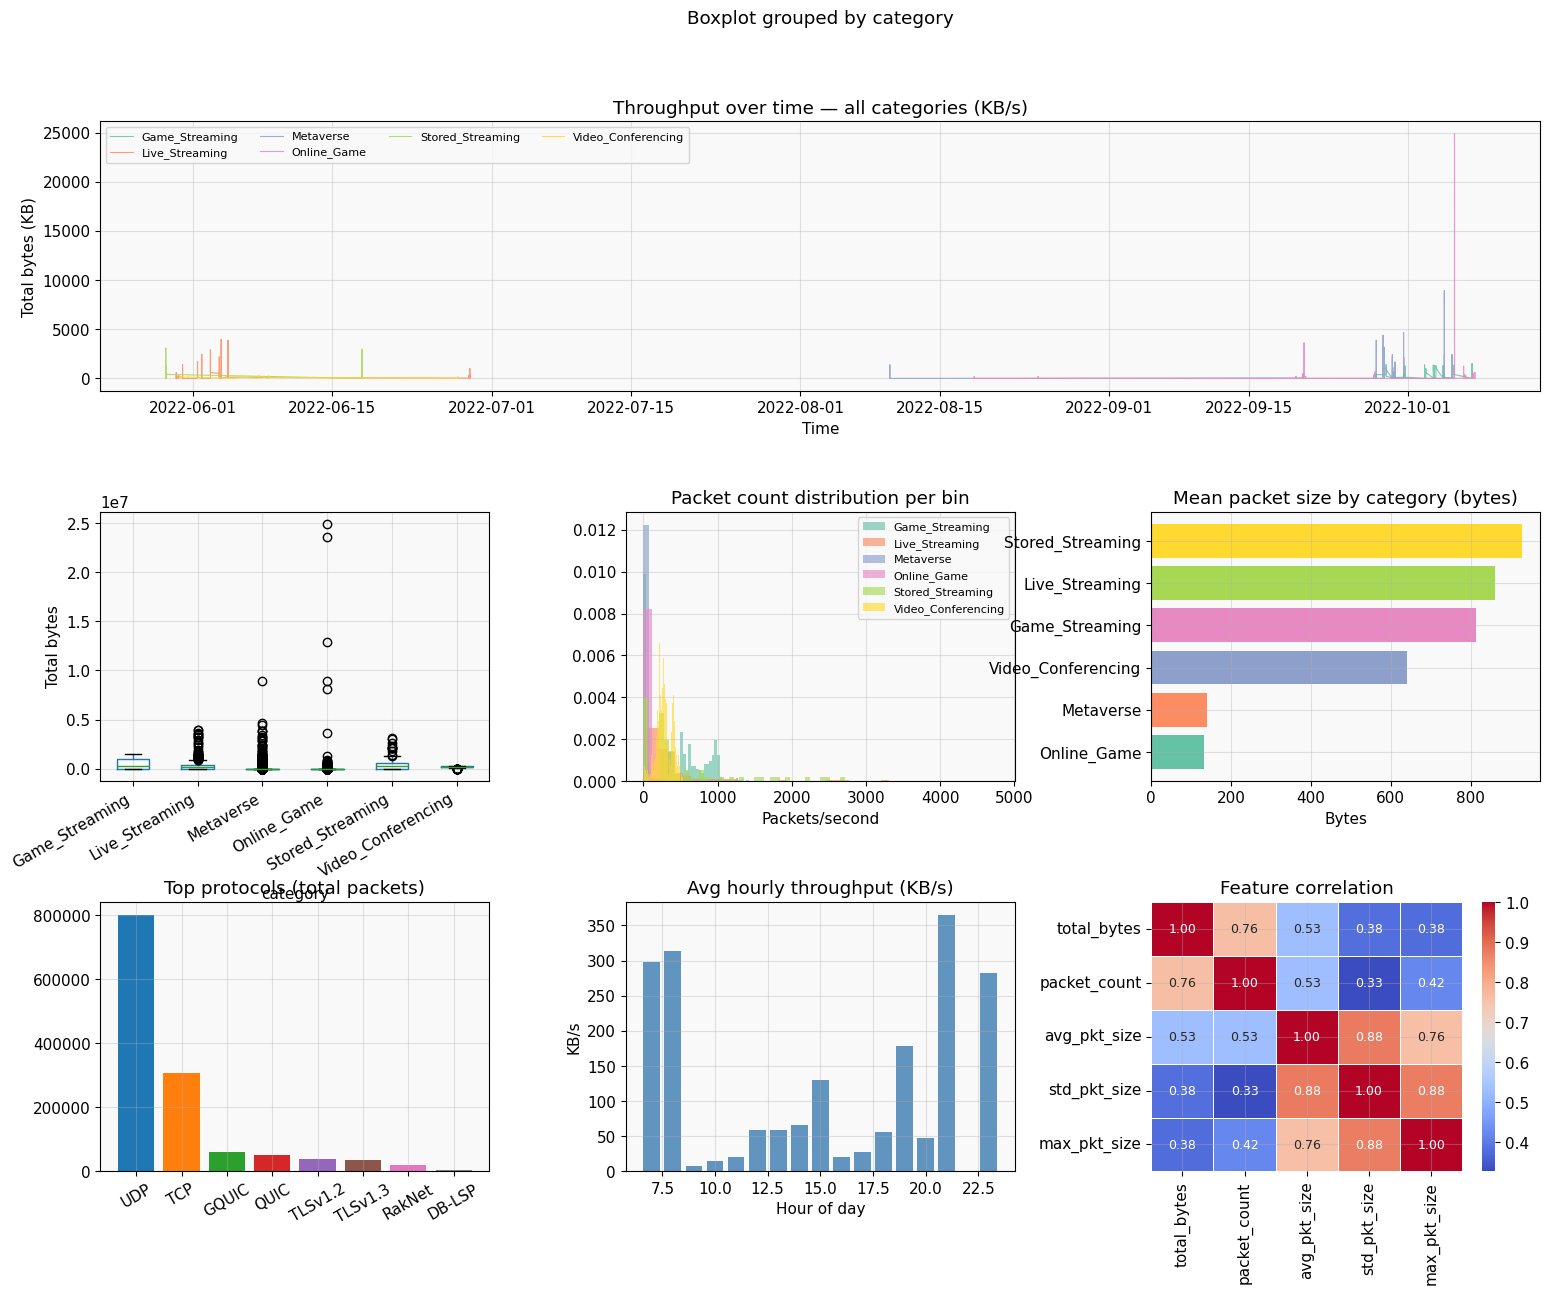

✓ EDA saved → /content/drive/MyDrive/5G_Project_Results/01_eda.png


In [12]:
print("\n═══ EDA ═══\n")
print(df_agg.describe().round(2))

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("5G Network Traffic — Exploratory Data Analysis", fontsize=15, fontweight="bold")

PALETTE = sns.color_palette("Set2", df_agg["category"].nunique())

# Plot 1: Total bytes over time (all categories)
ax1 = fig.add_subplot(gs[0, :])
for i, cat in enumerate(df_agg["category"].unique()):
    sub = df_agg[df_agg["category"] == cat].sort_values("timestamp")
    ax1.plot(sub["timestamp"], sub[TARGET] / 1e3, label=cat,
             linewidth=0.8, alpha=0.85, color=PALETTE[i])
ax1.set_title("Throughput over time — all categories (KB/s)")
ax1.set_xlabel("Time")
ax1.set_ylabel("Total bytes (KB)")
ax1.legend(fontsize=8, ncol=4)

# Plot 2: Throughput distribution per category
ax2 = fig.add_subplot(gs[1, 0])
df_agg.boxplot(column=TARGET, by="category", ax=ax2)
ax2.set_title("Throughput distribution by category")
plt.sca(ax2); plt.title(""); plt.xticks(rotation=30, ha="right")
ax2.set_ylabel("Total bytes")

# Plot 3: Packet count distribution
ax3 = fig.add_subplot(gs[1, 1])
for i, cat in enumerate(df_agg["category"].unique()):
    sub = df_agg[df_agg["category"] == cat]["packet_count"]
    ax3.hist(sub, bins=40, alpha=0.65, label=cat, color=PALETTE[i], density=True)
ax3.set_title("Packet count distribution per bin")
ax3.set_xlabel("Packets/second")
ax3.legend(fontsize=8)

# Plot 4: Average packet size by category
ax4 = fig.add_subplot(gs[1, 2])
cat_means = df_agg.groupby("category")["avg_pkt_size"].mean().sort_values(ascending=True)
ax4.barh(cat_means.index, cat_means.values, color=PALETTE[:len(cat_means)])
ax4.set_title("Mean packet size by category (bytes)")
ax4.set_xlabel("Bytes")

# Plot 5: Protocol mix (top protocols)
ax5 = fig.add_subplot(gs[2, 0])
proto_cols = [c for c in df_agg.columns if c.startswith("proto_")]
proto_totals = df_agg[proto_cols].sum().sort_values(ascending=False).head(8)
proto_totals.index = [c.replace("proto_", "") for c in proto_totals.index]
ax5.bar(proto_totals.index, proto_totals.values, color=sns.color_palette("tab10", len(proto_totals)))
ax5.set_title("Top protocols (total packets)")
ax5.tick_params(axis="x", rotation=30)

# Plot 6: Hourly traffic pattern
ax6 = fig.add_subplot(gs[2, 1])
df_agg["hour"] = df_agg["timestamp"].dt.hour
hourly = df_agg.groupby("hour")[TARGET].mean() / 1e3
ax6.bar(hourly.index, hourly.values, color="steelblue", alpha=0.85)
ax6.set_title("Avg hourly throughput (KB/s)")
ax6.set_xlabel("Hour of day")
ax6.set_ylabel("KB/s")

# Plot 7: Correlation heatmap
ax7 = fig.add_subplot(gs[2, 2])
corr_cols = ["total_bytes", "packet_count", "avg_pkt_size", "std_pkt_size", "max_pkt_size"]
corr_cols  = [c for c in corr_cols if c in df_agg.columns]
sns.heatmap(df_agg[corr_cols].corr(), ax=ax7, cmap="coolwarm", annot=True,
            fmt=".2f", linewidths=0.5, annot_kws={"size": 9})
ax7.set_title("Feature correlation")

plt.savefig(f"{SAVE_DIR}/01_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ EDA saved → {SAVE_DIR}/01_eda.png")



In [13]:
print("\n[PREPROCESSING]\n")

df_proc = df_agg.copy()

# ── 7a. IQR outlier capping (per category) ───────────────────────────
def cap_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

df_proc[TARGET] = df_proc.groupby("category")[TARGET].transform(cap_iqr)
print("✓ Outliers capped using IQR (per category).")

# ── 7b. Fill any remaining NaNs ──────────────────────────────────────
num_cols = df_proc.select_dtypes(include=np.number).columns
df_proc[num_cols] = df_proc[num_cols].fillna(df_proc[num_cols].median())
print("✓ Missing values filled with column medians.")

# ── 7c. Encode category label ─────────────────────────────────────────
le = LabelEncoder()
df_proc["category_enc"] = le.fit_transform(df_proc["category"])
print(f"✓ Category encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nPreprocessed shape: {df_proc.shape}")




[PREPROCESSING]

✓ Outliers capped using IQR (per category).
✓ Missing values filled with column medians.
✓ Category encoding: {'Game_Streaming': np.int64(0), 'Live_Streaming': np.int64(1), 'Metaverse': np.int64(2), 'Online_Game': np.int64(3), 'Stored_Streaming': np.int64(4), 'Video_Conferencing': np.int64(5)}

Preprocessed shape: (20961, 42)


In [14]:
print("\n[FEATURE ENGINEERING]\n")

df_feat = df_proc.sort_values(["category", "timestamp"]).copy()

# ── 8a. Time-based features ──────────────────────────────────────────
df_feat["hour"]         = df_feat["timestamp"].dt.hour
df_feat["day_of_week"]  = df_feat["timestamp"].dt.dayofweek
df_feat["is_weekend"]   = (df_feat["day_of_week"] >= 5).astype(int)
df_feat["is_peak"]      = df_feat["hour"].isin(range(18, 23)).astype(int)

# ── 8b. Cyclical time encoding (prevents hour-23→0 discontinuity) ────
df_feat["hour_sin"] = np.sin(2 * np.pi * df_feat["hour"] / 24)
df_feat["hour_cos"] = np.cos(2 * np.pi * df_feat["hour"] / 24)
df_feat["dow_sin"]  = np.sin(2 * np.pi * df_feat["day_of_week"] / 7)
df_feat["dow_cos"]  = np.cos(2 * np.pi * df_feat["day_of_week"] / 7)

# ── 8c. Lag features (per category group) ────────────────────────────
for lag in [1, 3, 5, 10, 15, 30]:
    df_feat[f"lag_{lag}"] = df_feat.groupby("category")[TARGET].shift(lag)

# ── 8d. Rolling window statistics (per category group) ───────────────
for w in [5, 15, 30]:
    g = df_feat.groupby("category")[TARGET]
    df_feat[f"roll_mean_{w}"] = g.transform(lambda x: x.rolling(w, min_periods=1).mean())
    df_feat[f"roll_std_{w}"]  = g.transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
    df_feat[f"roll_max_{w}"]  = g.transform(lambda x: x.rolling(w, min_periods=1).max())

# ── 8e. Exponential weighted mean ────────────────────────────────────
df_feat["ewm_5"]  = df_feat.groupby("category")[TARGET].transform(lambda x: x.ewm(span=5,  adjust=False).mean())
df_feat["ewm_15"] = df_feat.groupby("category")[TARGET].transform(lambda x: x.ewm(span=15, adjust=False).mean())

# ── Drop NaN rows created by lagging ─────────────────────────────────
df_feat = df_feat.dropna().reset_index(drop=True)

# ── Final feature list ────────────────────────────────────────────────
BASE_FEATS = ["packet_count", "avg_pkt_size", "std_pkt_size", "max_pkt_size", "category_enc"]
TIME_FEATS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend", "is_peak"]
LAG_FEATS  = [f"lag_{l}" for l in [1, 3, 5, 10, 15, 30]]
ROLL_FEATS = [f"roll_mean_{w}" for w in [5, 15, 30]] + \
             [f"roll_std_{w}"  for w in [5, 15, 30]] + \
             [f"roll_max_{w}"  for w in [5, 15, 30]]
EWM_FEATS  = ["ewm_5", "ewm_15"]
PROTO_FEATS = [c for c in df_feat.columns if c.startswith("proto_")]

FEATURE_COLS = BASE_FEATS + TIME_FEATS + LAG_FEATS + ROLL_FEATS + EWM_FEATS + PROTO_FEATS
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]

print(f"✓ Feature engineering complete.")
print(f"  Total feature columns : {len(FEATURE_COLS)}")
print(f"  Dataset shape         : {df_feat.shape}")
print(f"  Feature groups:")
print(f"    Base          : {len(BASE_FEATS)}")
print(f"    Time/cyclical : {len(TIME_FEATS)}")
print(f"    Lag           : {len(LAG_FEATS)}")
print(f"    Rolling       : {len(ROLL_FEATS)}")
print(f"    EWM           : {len(EWM_FEATS)}")
print(f"    Protocol      : {len(PROTO_FEATS)}")



[FEATURE ENGINEERING]

✓ Feature engineering complete.
  Total feature columns : 61
  Dataset shape         : (20781, 66)
  Feature groups:
    Base          : 5
    Time/cyclical : 6
    Lag           : 6
    Rolling       : 9
    EWM           : 2
    Protocol      : 33



[★ NOVELTY #1] Anomaly Detection — Isolation Forest

✓ Anomalies detected: 1,039  (5.00% of time-series points)


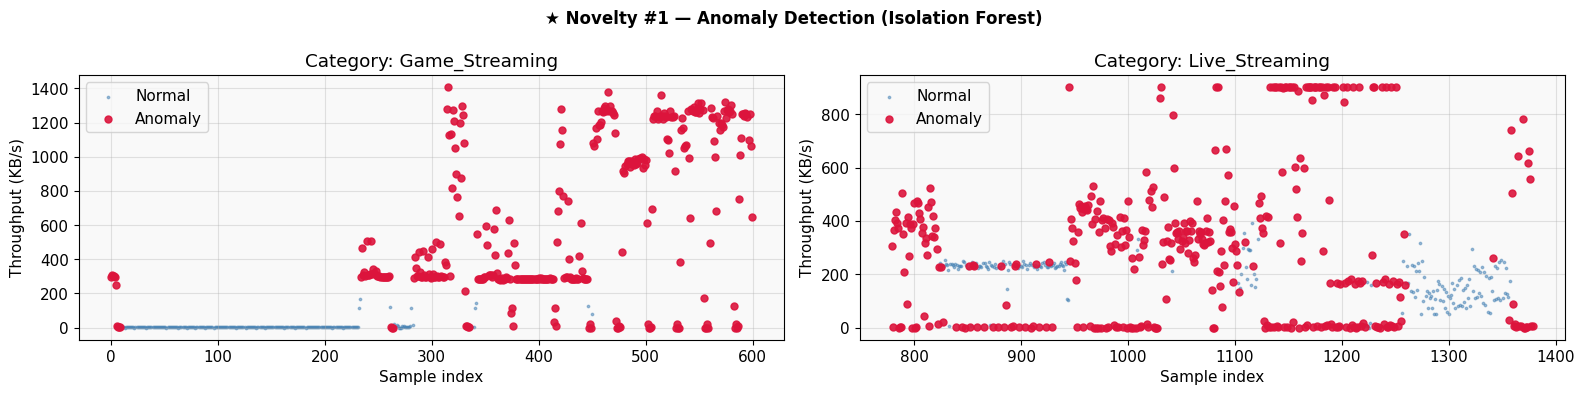

✓ Anomaly plot saved → /content/drive/MyDrive/5G_Project_Results/02_anomalies.png


In [15]:
print("\n[★ NOVELTY #1] Anomaly Detection — Isolation Forest\n")

iso_feats = ["lag_1", "lag_3", "lag_5", "roll_mean_5", "roll_std_5", "ewm_5", "packet_count"]
iso_feats = [c for c in iso_feats if c in df_feat.columns]

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,      # Assume ~5% traffic bursts are anomalous
    random_state=42,
    n_jobs=-1
)
df_feat["anomaly_score"] = iso_forest.fit_predict(df_feat[iso_feats])
df_feat["is_anomaly"]    = (df_feat["anomaly_score"] == -1).astype(int)

n_anom  = df_feat["is_anomaly"].sum()
pct_anom = n_anom / len(df_feat) * 100
print(f"✓ Anomalies detected: {n_anom:,}  ({pct_anom:.2f}% of time-series points)")

# ── Visualize anomalies ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("★ Novelty #1 — Anomaly Detection (Isolation Forest)", fontsize=12, fontweight="bold")

for idx, cat in enumerate(df_feat["category"].unique()[:2]):   # Show 2 categories
    sub     = df_feat[df_feat["category"] == cat].head(600)
    normal  = sub[sub["is_anomaly"] == 0]
    anomaly = sub[sub["is_anomaly"] == 1]
    ax = axes[idx]
    ax.scatter(normal.index,  normal[TARGET]  / 1e3, s=3,  alpha=0.5, color="steelblue", label="Normal")
    ax.scatter(anomaly.index, anomaly[TARGET] / 1e3, s=25, alpha=0.9, color="crimson",   label="Anomaly", zorder=5)
    ax.set_title(f"Category: {cat}")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Throughput (KB/s)")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/02_anomalies.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Anomaly plot saved → {SAVE_DIR}/02_anomalies.png")

# Add anomaly flag to feature columns
FEATURE_COLS.append("is_anomaly")


In [18]:
print("\n[TRAIN / TEST SPLIT]\n")

# Time-series split: last 20% = test (NO random shuffle — preserves temporal order)
split_idx = int(len(df_feat) * 0.80)
train_df  = df_feat.iloc[:split_idx].copy()
test_df   = df_feat.iloc[split_idx:].copy()

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET].values

# Scale features
feat_scaler   = MinMaxScaler()
target_scaler = MinMaxScaler()

X_train_sc = feat_scaler.fit_transform(X_train)
X_test_sc  = feat_scaler.transform(X_test)

y_train_sc = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

# Reshape for LSTM: [samples, timesteps=1, features]
X_train_3d = X_train_sc.reshape(-1, 1, X_train_sc.shape[1])
X_test_3d  = X_test_sc.reshape(-1, 1, X_test_sc.shape[1])

print(f"✓ Train samples : {len(y_train):,}")
print(f"✓ Test  samples : {len(y_test):,}")
print(f"✓ Features      : {len(FEATURE_COLS)}")

# Helper functions
def inv(arr):
    """Inverse-scale predictions back to original bytes."""
    return target_scaler.inverse_transform(np.array(arr).reshape(-1, 1)).ravel()

def metrics(y_true, y_pred, name):
    """Compute and return RMSE, MAE, MAPE."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"  [{name}]  RMSE={rmse:,.1f}  MAE={mae:,.1f}  MAPE={mape:.2f}%")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape}

CALLBACKS = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=0)
]

all_results = []




[TRAIN / TEST SPLIT]

✓ Train samples : 16,624
✓ Test  samples : 4,157
✓ Features      : 63


In [19]:
print("\n[BASELINE 1] Auto-ARIMA\n")

# ARIMA is univariate — use a manageable sample
N_ARIMA = min(3000, len(y_train))
N_TEST  = min(300,  len(y_test))

arima_model = pm.auto_arima(
    y_train[:N_ARIMA],
    seasonal=False,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    max_p=5, max_q=5, max_d=2
)
print(f"✓ Best ARIMA order: {arima_model.order}")

arima_preds = arima_model.predict(n_periods=N_TEST)
arima_preds = np.maximum(arima_preds, 0)

res_arima = metrics(y_test[:N_TEST], arima_preds, "Auto-ARIMA")
all_results.append(res_arima)


[BASELINE 1] Auto-ARIMA

✓ Best ARIMA order: (5, 1, 3)
  [Auto-ARIMA]  RMSE=4,970.5  MAE=2,973.2  MAPE=145.64%


In [20]:
print("\n[BASELINE 2] LSTM\n")

lstm_model = Sequential([
    Input(shape=(1, X_train_3d.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
], name="LSTM_Baseline")
lstm_model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_3d, y_train_sc,
    validation_split=0.15,
    epochs=60,
    batch_size=128,
    callbacks=CALLBACKS,
    verbose=1
)

lstm_preds = inv(lstm_model.predict(X_test_3d, verbose=0).ravel())
res_lstm   = metrics(y_test, lstm_preds, "LSTM (baseline)")
all_results.append(res_lstm)



[BASELINE 2] LSTM



Model: "LSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,273 (180.75 KB)

 Trainable params: 46,273 (180.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0038 - mae: 0.0213 - val_loss: 2.1199e-05 - val_mae: 0.0039 - learning_rate: 0.0010
Epoch 2/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014 - mae: 0.0121 - val_loss: 1.1035e-05 - val_mae: 0.0025 - learning_rate: 0.0010
Epoch 3/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.4538e-04 - mae: 0.0091 - val_loss: 3.4747e-05 - val_mae: 0.0051 - learning_rate: 0.0010
Epoch 4/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6814e-04 - mae: 0.0079 - val_loss: 1.9497e-05 - val_mae: 0.0036 - learning_rate: 0.0010
Epoch 5/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.7549e-04 - mae: 0.0071 - val_loss: 1.7228e-05 - val_mae: 0.0033 - learning_rate: 5.0000e-04
Epoch 6/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.8668e-04 - mae: 0.0066 - val_loss: 2.0208e-05 - val_mae: 0.0038 - learning_rate: 5.0000e-04
Epoch 7/60
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.2585e-04 - mae: 0.0068 - val_loss: 4.

In [21]:
print("\n[BASELINE 3] XGBoost\n")

xgb_model = xgb.XGBRegressor(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    early_stopping_rounds=25,
    random_state=42,
    n_jobs=-1,
    verbosity=1
)
xgb_model.fit(
    X_train_sc, y_train_sc,
    eval_set=[(X_test_sc, y_test_sc)],
    verbose=100
)

xgb_preds = inv(xgb_model.predict(X_test_sc))
res_xgb   = metrics(y_test, xgb_preds, "XGBoost (baseline)")
all_results.append(res_xgb)




[BASELINE 3] XGBoost

[0]	validation_0-rmse:0.05872
[100]	validation_0-rmse:0.01813
[200]	validation_0-rmse:0.01771
[258]	validation_0-rmse:0.01771
  [XGBoost (baseline)]  RMSE=26,819.7  MAE=7,297.6  MAPE=37.74%


In [23]:
print("\n[★ NOVELTY #2] Bidirectional LSTM — Advanced Model\n")

inp = Input(shape=(1, X_train_3d.shape[2]))
x   = Bidirectional(LSTM(128, return_sequences=True))(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.25)(x)
x   = Bidirectional(LSTM(64))(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(64, activation="relu")(x)
x   = Dropout(0.15)(x)
x   = Dense(32, activation="relu")(x)
out = Dense(1)(x)

bilstm_model = Model(inp, out, name="BiLSTM_Advanced")
bilstm_model.compile(optimizer=Adam(5e-4), loss="mse", metrics=["mae"])
bilstm_model.summary()

history_bilstm = bilstm_model.fit(
    X_train_3d, y_train_sc,
    validation_split=0.15,
    epochs=80,
    batch_size=128,
    callbacks=CALLBACKS,
    verbose=1
)

bilstm_preds = inv(bilstm_model.predict(X_test_3d, verbose=0).ravel())
res_bilstm   = metrics(y_test, bilstm_preds, "BiLSTM (★ Novelty #2)")
all_results.append(res_bilstm)



[★ NOVELTY #2] Bidirectional LSTM — Advanced Model



Model: "BiLSTM_Advanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1, 63)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1, 256)         │       196,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 372,865 (1.42 MB)

 Trainable params: 372,097 (1.42 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1555 - mae: 0.2775 - val_loss: 2.2417e-04 - val_mae: 0.0147 - learning_rate: 5.0000e-04
Epoch 2/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0429 - mae: 0.1525 - val_loss: 3.7222e-04 - val_mae: 0.0189 - learning_rate: 5.0000e-04
Epoch 3/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0264 - mae: 0.1191 - val_loss: 8.0019e-04 - val_mae: 0.0278 - learning_rate: 5.0000e-04
Epoch 4/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0202 - mae: 0.1032 - val_loss: 4.6637e-04 - val_mae: 0.0203 - learning_rate: 2.5000e-04
Epoch 5/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0165 - mae: 0.0922 - val_loss: 6.9391e-04 - val_mae: 0.0223 - learning_rate: 2.5000e-04
Epoch 6/80
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0135 - mae: 0.0845 - val_loss: 0.0012 - val_mae: 0.0271 - learning_rate: 2.5000e-04
  [BiLSTM (★ Novelty #2)]  RMSE=106,050.9  MAE=48,305.2  MAPE=1069.78%


In [24]:
print("\n[★ NOVELTY #2] BiLSTM + XGBoost Ensemble\n")

val_n = int(len(y_test) * 0.3)
best_rmse, best_w = np.inf, (0.5, 0.5)

for w in np.arange(0.05, 1.0, 0.05):
    blend = w * bilstm_preds[:val_n] + (1 - w) * xgb_preds[:val_n]
    r     = np.sqrt(mean_squared_error(y_test[:val_n], blend))
    if r < best_rmse:
        best_rmse, best_w = r, (round(w, 2), round(1 - w, 2))

print(f"✓ Optimal weights — BiLSTM: {best_w[0]}, XGBoost: {best_w[1]}")
ensemble_preds = best_w[0] * bilstm_preds + best_w[1] * xgb_preds
res_ensemble   = metrics(y_test, ensemble_preds, "BiLSTM+XGB Ensemble (★)")
all_results.append(res_ensemble)




[★ NOVELTY #2] BiLSTM + XGBoost Ensemble

✓ Optimal weights — BiLSTM: 0.05, XGBoost: 0.95
  [BiLSTM+XGB Ensemble (★)]  RMSE=30,250.7  MAE=8,491.3  MAPE=55.96%


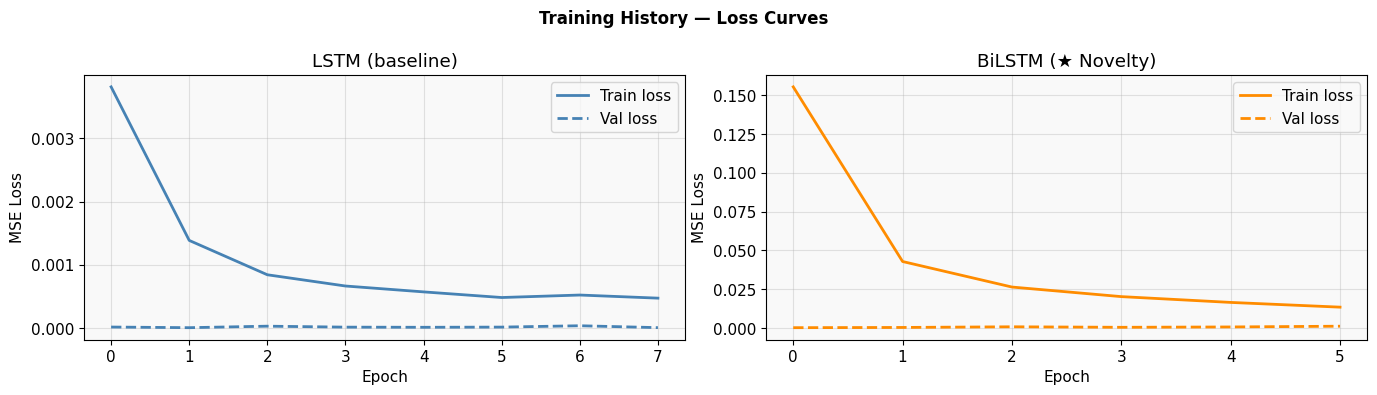

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Training History — Loss Curves", fontsize=12, fontweight="bold")

for ax, hist, name, col in [
    (axes[0], history_lstm,   "LSTM (baseline)",    "steelblue"),
    (axes[1], history_bilstm, "BiLSTM (★ Novelty)", "darkorange"),
]:
    ax.plot(hist.history["loss"],     label="Train loss", color=col, linewidth=2)
    ax.plot(hist.history["val_loss"], label="Val loss",   color=col, linewidth=2, linestyle="--")
    ax.set_title(f"{name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/03_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()



[EVALUATION & COMPARISON]

════════════════════════════════════════════════════════════
  MODEL PERFORMANCE COMPARISON
════════════════════════════════════════════════════════════
                              RMSE       MAE  MAPE (%)
Model                                                 
Auto-ARIMA                 4970.53   2973.19    145.64
LSTM (baseline)           53229.53  21674.58    747.71
XGBoost (baseline)        26819.74   7297.63     37.74
BiLSTM (★ Novelty #2)     95650.74  30284.22    687.83
BiLSTM (★ Novelty #2)    106050.91  48305.20   1069.78
BiLSTM+XGB Ensemble (★)   30250.69   8491.34     55.96
════════════════════════════════════════════════════════════

  🏆 Best model : Auto-ARIMA


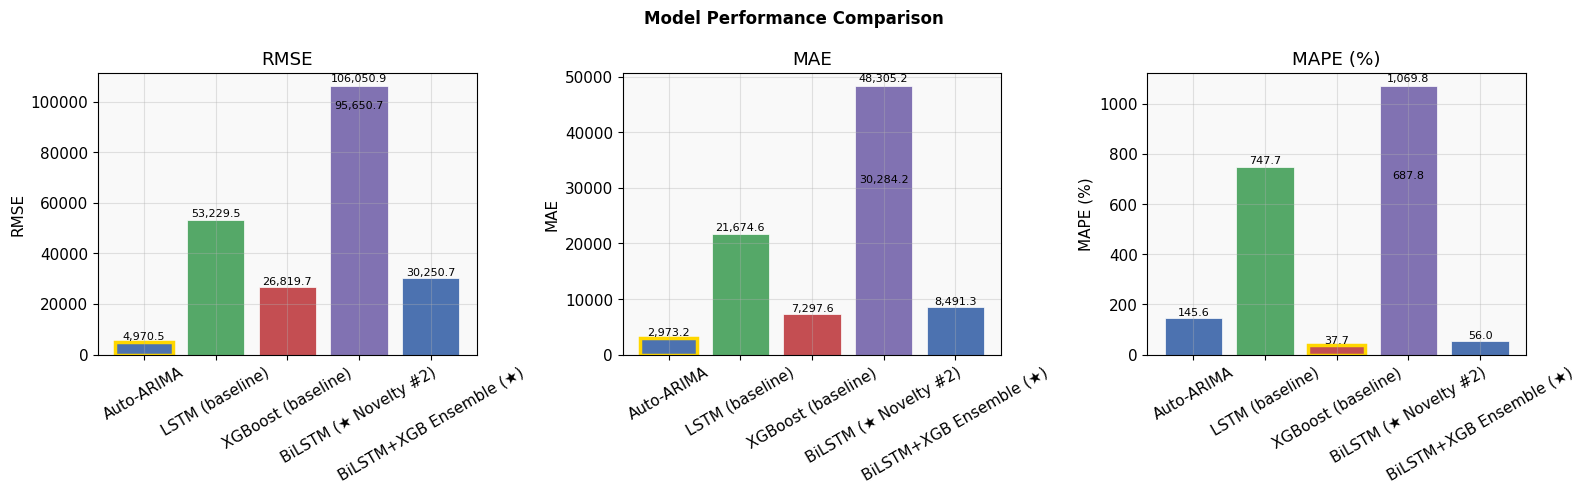

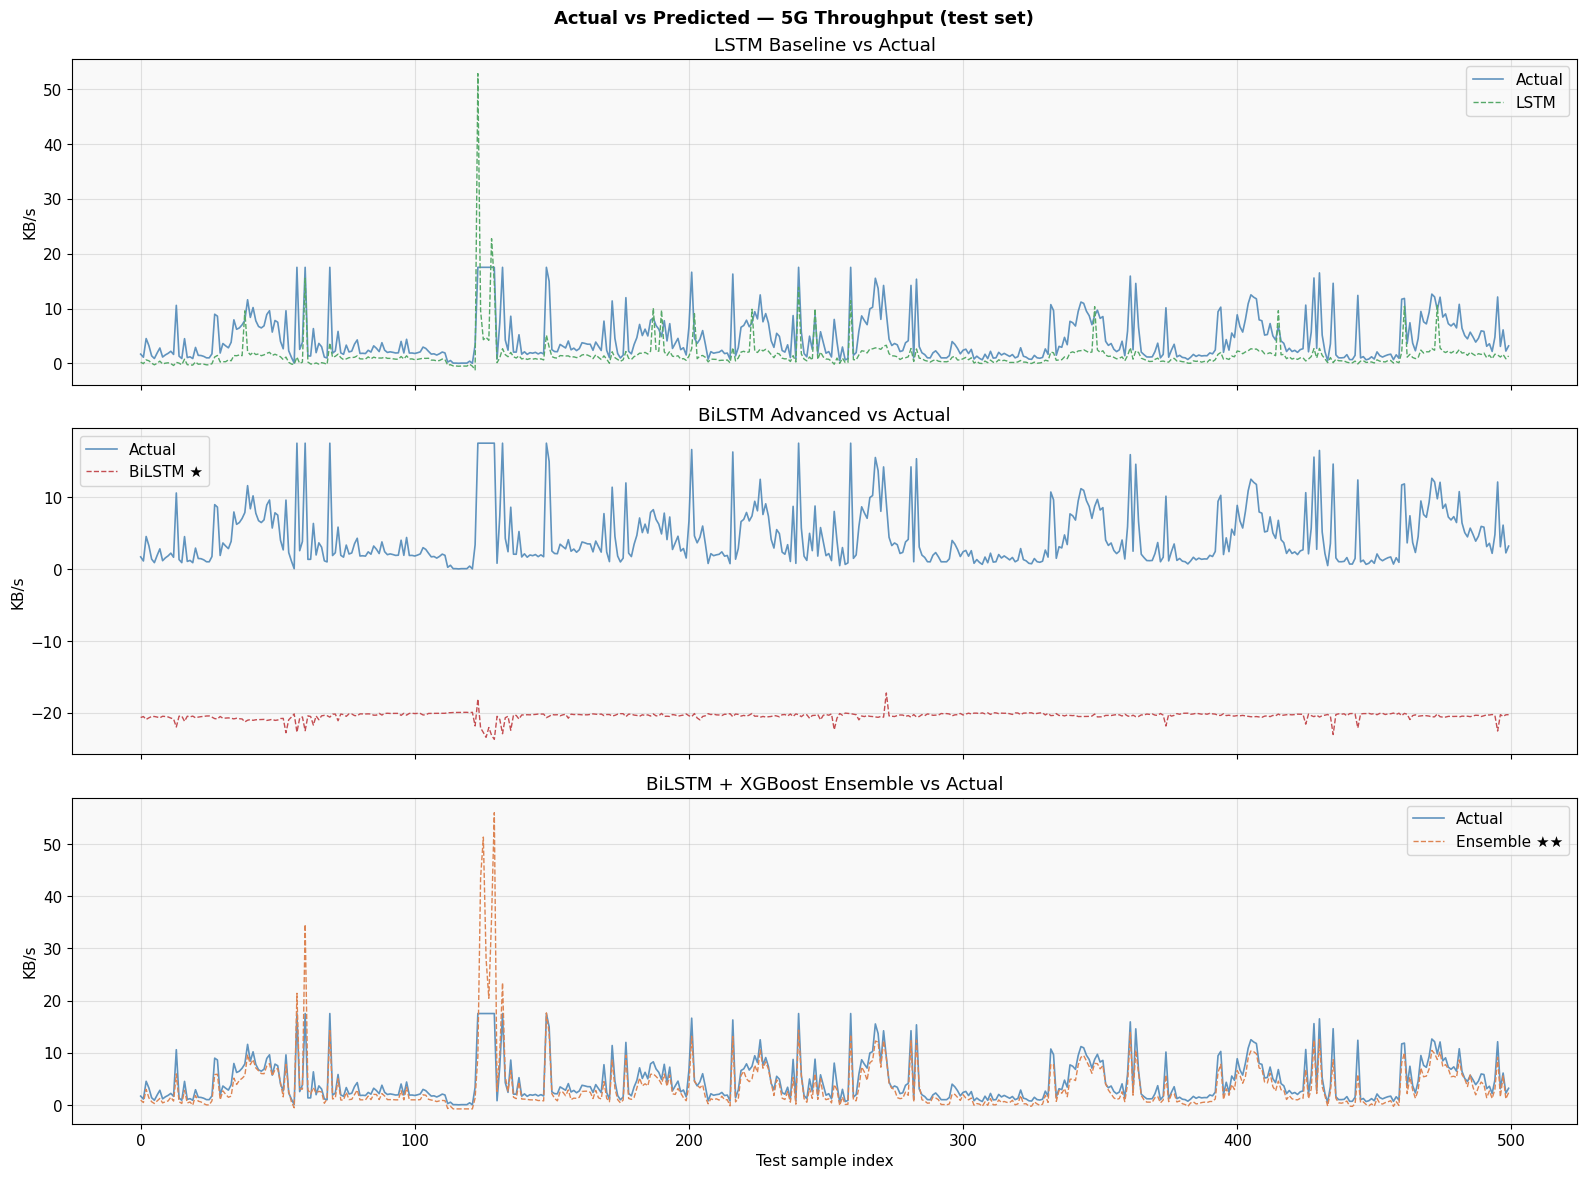

✓ Prediction plots saved → /content/drive/MyDrive/5G_Project_Results/


In [26]:
print("\n[EVALUATION & COMPARISON]\n")

results_df   = pd.DataFrame(all_results).set_index("Model")
best_model   = results_df["RMSE"].idxmin()

print("═" * 60)
print("  MODEL PERFORMANCE COMPARISON")
print("═" * 60)
print(results_df.round(2).to_string())
print("═" * 60)
print(f"\n  🏆 Best model : {best_model}")

# ── Bar charts ────────────────────────────────────────────────────────
colors   = ["#4C72B0", "#55A868", "#C44E52", "#DD8452", "#8172B2"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Performance Comparison", fontsize=12, fontweight="bold")

for ax, metric in zip(axes, ["RMSE", "MAE", "MAPE (%)"]):
    bars = ax.bar(results_df.index, results_df[metric],
                  color=colors[:len(results_df)], edgecolor="white", linewidth=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    # Gold border on best bar
    best_i = results_df[metric].values.argmin()
    bars[best_i].set_edgecolor("gold")
    bars[best_i].set_linewidth(2.5)
    # Value labels on bars
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f"{bar.get_height():,.1f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/04_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Actual vs Predicted ───────────────────────────────────────────────
PLOT_N = min(500, len(y_test))
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Actual vs Predicted — 5G Throughput (test set)", fontsize=13, fontweight="bold")

x_ax = range(PLOT_N)
axes[0].plot(x_ax, y_test[:PLOT_N] / 1e3, "steelblue",  linewidth=1.2, label="Actual", alpha=0.85)
axes[0].plot(x_ax, lstm_preds[:PLOT_N] / 1e3,   "--", color="#55A868", linewidth=1, label="LSTM")
axes[0].set_title("LSTM Baseline vs Actual")
axes[0].set_ylabel("KB/s"); axes[0].legend()

axes[1].plot(x_ax, y_test[:PLOT_N] / 1e3, "steelblue",  linewidth=1.2, label="Actual", alpha=0.85)
axes[1].plot(x_ax, bilstm_preds[:PLOT_N] / 1e3, "--", color="#C44E52", linewidth=1, label="BiLSTM ★")
axes[1].set_title("BiLSTM Advanced vs Actual")
axes[1].set_ylabel("KB/s"); axes[1].legend()

axes[2].plot(x_ax, y_test[:PLOT_N] / 1e3, "steelblue",  linewidth=1.2, label="Actual", alpha=0.85)
axes[2].plot(x_ax, ensemble_preds[:PLOT_N] / 1e3, "--", color="#DD8452", linewidth=1, label="Ensemble ★★")
axes[2].set_title("BiLSTM + XGBoost Ensemble vs Actual")
axes[2].set_xlabel("Test sample index")
axes[2].set_ylabel("KB/s"); axes[2].legend()

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/05_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Prediction plots saved → {SAVE_DIR}/")



[★ NOVELTY #3] SHAP Explainability



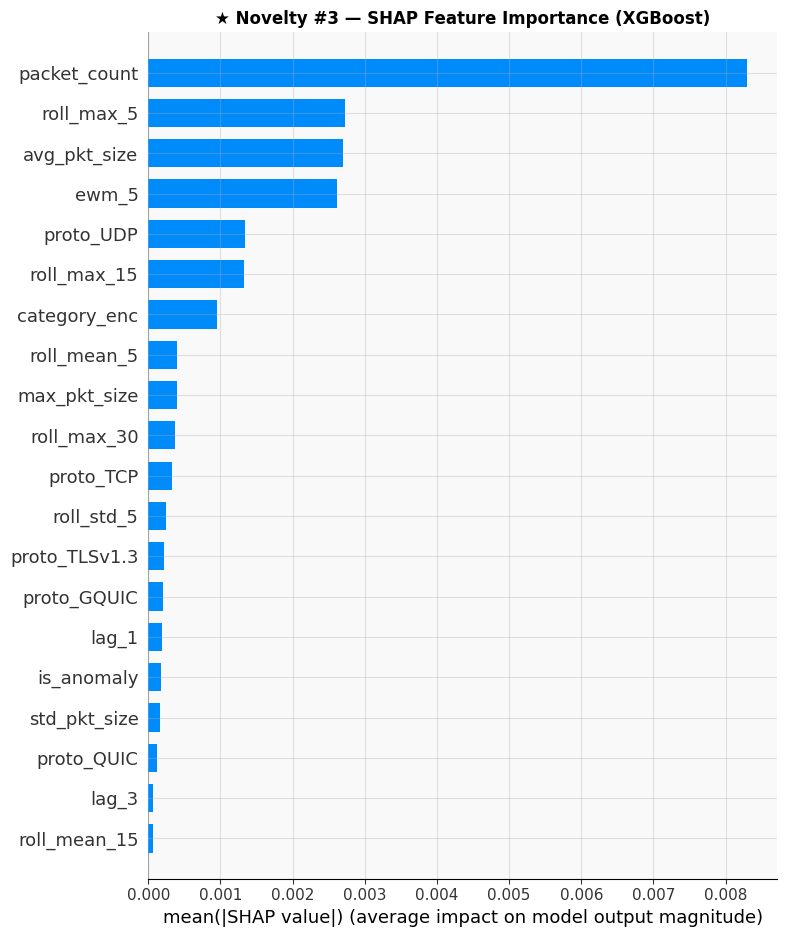

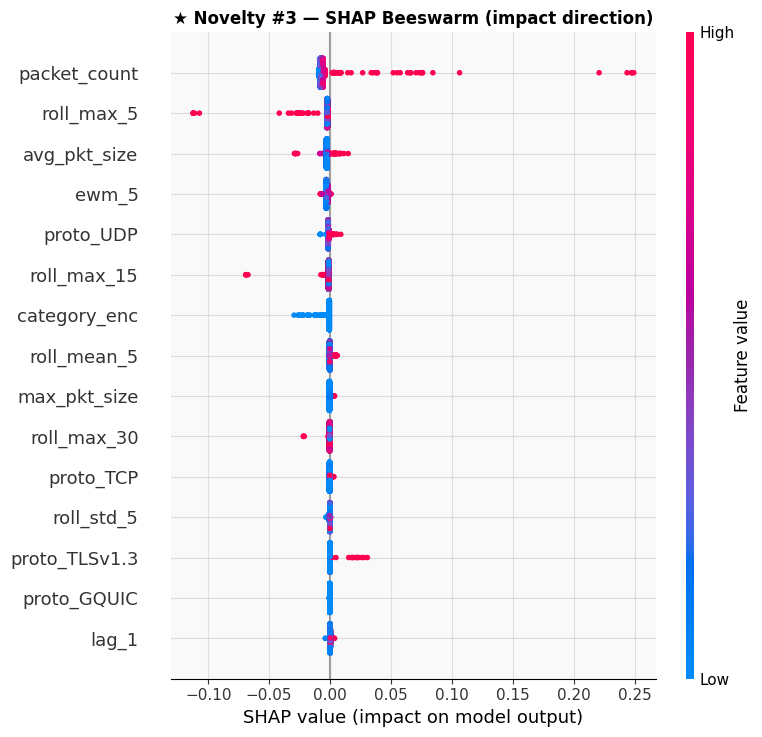


Top 15 most influential features:


,Feature,SHAP Importance
0,packet_count,0.008297
1,roll_max_5,0.002733
2,avg_pkt_size,0.002696
3,ewm_5,0.002609
4,proto_UDP,0.001346
5,roll_max_15,0.001332
6,category_enc,0.000949
7,roll_mean_5,0.000403
8,max_pkt_size,0.000402
9,roll_max_30,0.000375



✓ SHAP plots saved → /content/drive/MyDrive/5G_Project_Results/


In [27]:
print("\n[★ NOVELTY #3] SHAP Explainability\n")

SHAP_N     = min(2000, len(X_test_sc))
X_shap     = X_test_sc[:SHAP_N]

explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_shap)

# ── Bar plot: global feature importance ──────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURE_COLS,
                  plot_type="bar", show=False, max_display=20)
plt.title("★ Novelty #3 — SHAP Feature Importance (XGBoost)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/06_shap_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Beeswarm: direction of feature impact ────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_shap, feature_names=FEATURE_COLS,
                  show=False, max_display=15)
plt.title("★ Novelty #3 — SHAP Beeswarm (impact direction)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/07_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Top features summary ──────────────────────────────────────────────
mean_shap  = np.abs(shap_vals).mean(axis=0)
shap_df    = pd.DataFrame({"Feature": FEATURE_COLS, "SHAP Importance": mean_shap})
shap_df    = shap_df.sort_values("SHAP Importance", ascending=False).head(15)
print("\nTop 15 most influential features:")
display(shap_df.reset_index(drop=True))
print(f"\n✓ SHAP plots saved → {SAVE_DIR}/")




[★ NOVELTY #4] Real-Time Prediction & Alert Simulation

Alert threshold   : 7.2 KB/s  (90th percentile of training traffic)
Alert events      : 7 / 60 time steps


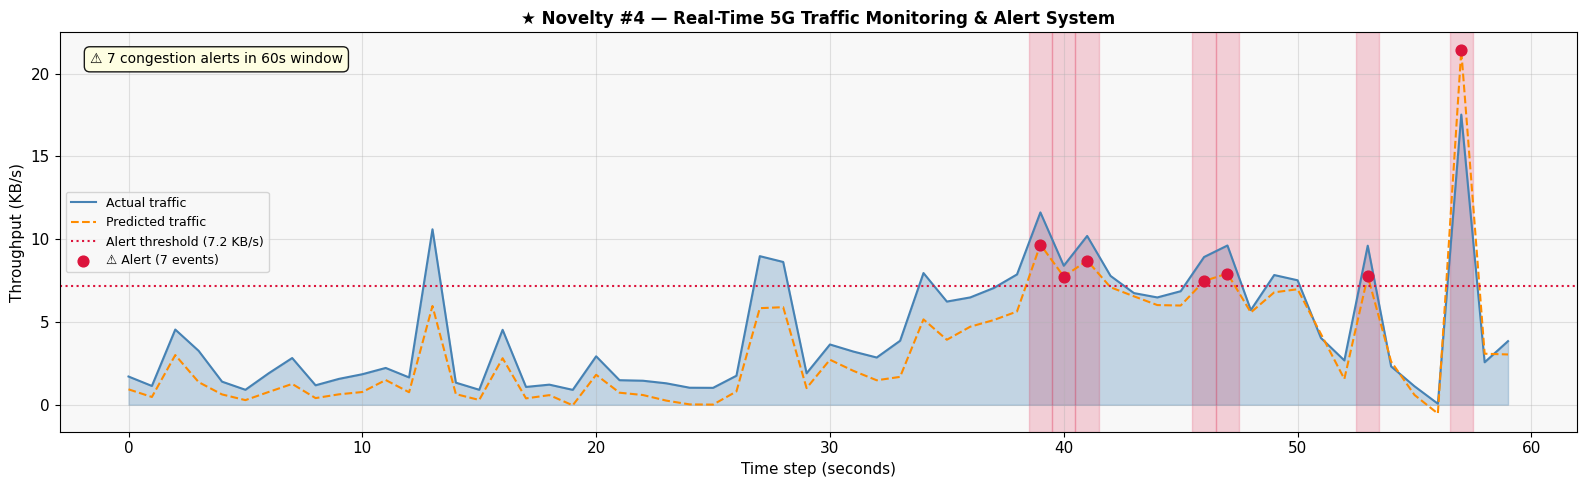

✓ Alert simulation saved → /content/drive/MyDrive/5G_Project_Results/08_realtime_alerts.png


In [28]:
print("\n[★ NOVELTY #4] Real-Time Prediction & Alert Simulation\n")

ALERT_THRESHOLD = np.percentile(y_train, 90)   # Alert if predicted > 90th percentile of training
WINDOW          = 60                             # Simulate 60 time steps

sim_actual = y_test[:WINDOW]
sim_pred   = ensemble_preds[:WINDOW]
sim_time   = test_df["timestamp"].values[:WINDOW]

alerts     = sim_pred > ALERT_THRESHOLD
n_alerts   = alerts.sum()

print(f"Alert threshold   : {ALERT_THRESHOLD/1e3:.1f} KB/s  (90th percentile of training traffic)")
print(f"Alert events      : {n_alerts} / {WINDOW} time steps")

fig, ax = plt.subplots(figsize=(16, 5))
ax.set_facecolor("#f8f8f8")

ax.fill_between(range(WINDOW), sim_actual / 1e3, alpha=0.3, color="steelblue")
ax.plot(range(WINDOW), sim_actual / 1e3,  color="steelblue", linewidth=1.5, label="Actual traffic")
ax.plot(range(WINDOW), sim_pred   / 1e3,  color="darkorange", linewidth=1.5, linestyle="--", label="Predicted traffic")
ax.axhline(ALERT_THRESHOLD / 1e3, color="crimson", linewidth=1.5, linestyle=":", label=f"Alert threshold ({ALERT_THRESHOLD/1e3:.1f} KB/s)")

for i, alert in enumerate(alerts):
    if alert:
        ax.axvspan(i - 0.5, i + 0.5, color="crimson", alpha=0.18)

ax.scatter(np.where(alerts)[0], sim_pred[alerts] / 1e3,
           color="crimson", s=60, zorder=5, label=f"⚠ Alert ({n_alerts} events)")

ax.set_title("★ Novelty #4 — Real-Time 5G Traffic Monitoring & Alert System", fontsize=12, fontweight="bold")
ax.set_xlabel("Time step (seconds)")
ax.set_ylabel("Throughput (KB/s)")
ax.legend(fontsize=9)

props = dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.9)
ax.text(0.02, 0.95, f"⚠ {n_alerts} congestion alerts in {WINDOW}s window",
        transform=ax.transAxes, fontsize=10, verticalalignment="top", bbox=props)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/08_realtime_alerts.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Alert simulation saved → {SAVE_DIR}/08_realtime_alerts.png")


[★ NOVELTY #5] Traffic Prediction Heatmaps



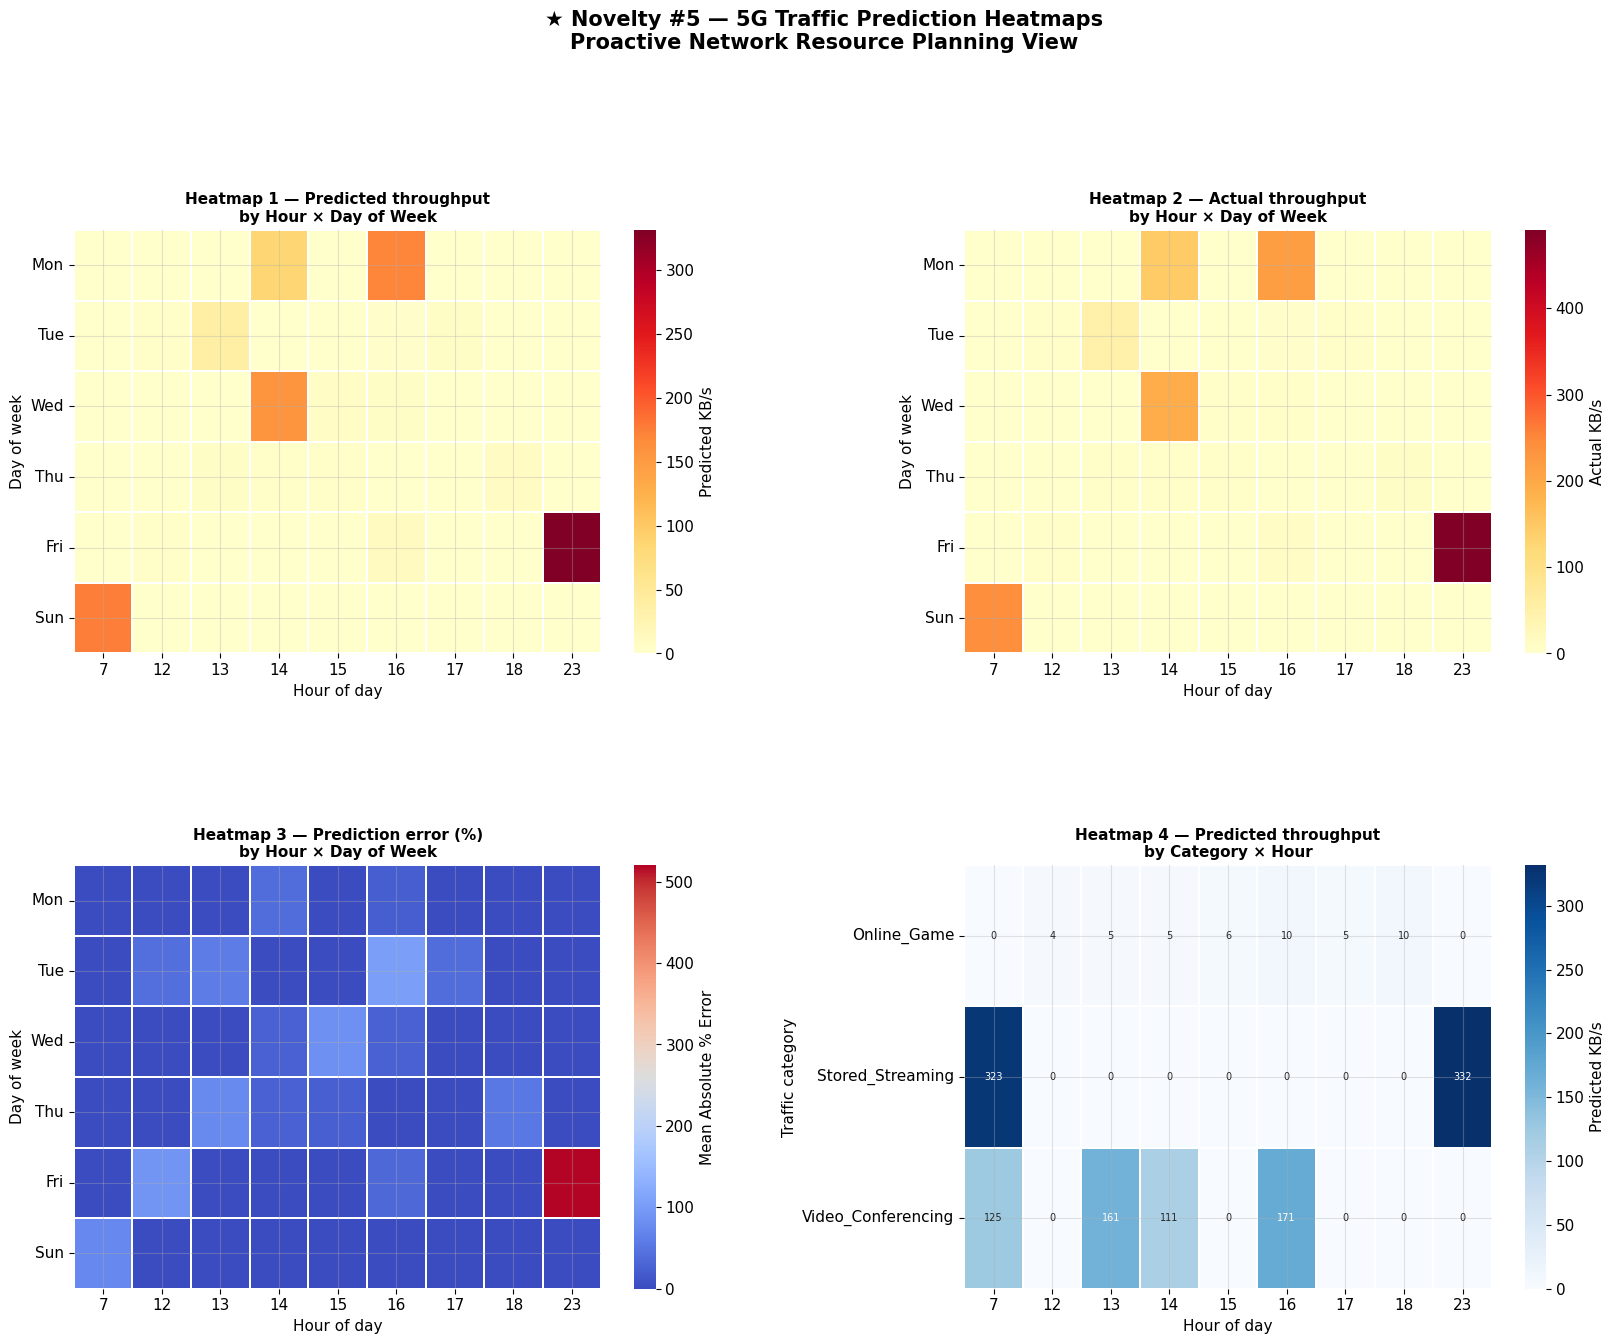

In [31]:
print("\n[★ NOVELTY #5] Traffic Prediction Heatmaps\n")

import matplotlib.ticker as mticker

# ── Attach predictions and time info to test set ──────────────────────
hm_df = test_df[["timestamp", "category"]].copy().reset_index(drop=True)
hm_df["actual"]    = y_test
hm_df["predicted"] = ensemble_preds
hm_df["error"]     = np.abs(hm_df["actual"] - hm_df["predicted"])
hm_df["error_pct"] = (hm_df["error"] / hm_df["actual"].replace(0, np.nan)) * 100
hm_df["hour"]      = hm_df["timestamp"].dt.hour
hm_df["day_name"]  = hm_df["timestamp"].dt.strftime("%a")   # Mon, Tue...
hm_df["day_num"]   = hm_df["timestamp"].dt.dayofweek        # 0=Mon
hm_df["week"]      = hm_df["timestamp"].dt.isocalendar().week.astype(int)

DAY_ORDER  = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
KB         = 1e3   # convert bytes → KB for readability

fig = plt.figure(figsize=(20, 22))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle("★ Novelty #5 — 5G Traffic Prediction Heatmaps\n"
             "Proactive Network Resource Planning View",
             fontsize=15, fontweight="bold", y=0.98)

# ────────────────────────────────────────────────────────────────────
# HEATMAP 1 — Predicted Throughput: Hour × Day of Week
# "When does 5G traffic peak during the week?"
# ────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

pivot1 = (hm_df.groupby(["day_name", "hour"])["predicted"]
               .mean()
               .unstack(fill_value=0) / KB)

# Reorder days Mon→Sun
pivot1 = pivot1.reindex([d for d in DAY_ORDER if d in pivot1.index])

sns.heatmap(pivot1, ax=ax1, cmap="YlOrRd", linewidths=0.3,
            linecolor="white", cbar_kws={"label": "Predicted KB/s"})
ax1.set_title("Heatmap 1 — Predicted throughput\nby Hour × Day of Week",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Day of week")
ax1.tick_params(axis="x", rotation=0)
ax1.tick_params(axis="y", rotation=0)

# ────────────────────────────────────────────────────────────────────
# HEATMAP 2 — Actual Throughput: Hour × Day of Week
# Side-by-side comparison with Heatmap 1
# ────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

pivot2 = (hm_df.groupby(["day_name", "hour"])["actual"]
               .mean()
               .unstack(fill_value=0) / KB)
pivot2 = pivot2.reindex([d for d in DAY_ORDER if d in pivot2.index])

sns.heatmap(pivot2, ax=ax2, cmap="YlOrRd", linewidths=0.3,
            linecolor="white", cbar_kws={"label": "Actual KB/s"})
ax2.set_title("Heatmap 2 — Actual throughput\nby Hour × Day of Week",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Hour of day")
ax2.set_ylabel("Day of week")
ax2.tick_params(axis="x", rotation=0)
ax2.tick_params(axis="y", rotation=0)

# ────────────────────────────────────────────────────────────────────
# HEATMAP 3 — Prediction Error: Hour × Day of Week
# "When is the model least accurate?" (guides retraining schedule)
# ────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

pivot3 = (hm_df.groupby(["day_name", "hour"])["error_pct"]
               .mean()
               .unstack(fill_value=0))
pivot3 = pivot3.reindex([d for d in DAY_ORDER if d in pivot3.index])

sns.heatmap(pivot3, ax=ax3, cmap="coolwarm", linewidths=0.3,
            linecolor="white", cbar_kws={"label": "Mean Absolute % Error"},
            vmin=0)
ax3.set_title("Heatmap 3 — Prediction error (%)\nby Hour × Day of Week",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Hour of day")
ax3.set_ylabel("Day of week")
ax3.tick_params(axis="x", rotation=0)
ax3.tick_params(axis="y", rotation=0)

# ────────────────────────────────────────────────────────────────────
# HEATMAP 4 — Predicted Throughput: Category × Hour
# "Which traffic type dominates at each hour?"
# ────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])

pivot4 = (hm_df.groupby(["category", "hour"])["predicted"]
               .mean()
               .unstack(fill_value=0) / KB)

sns.heatmap(pivot4, ax=ax4, cmap="Blues", linewidths=0.3,
            linecolor="white", annot=(pivot4.shape[0] <= 8),
            fmt=".0f", annot_kws={"size": 7},
            cbar_kws={"label": "Predicted KB/s"})
ax4.set_title("Heatmap 4 — Predicted throughput\nby Category × Hour",
              fontsize=11, fontweight="bold")
ax4.set_xlabel("Hour of day")
ax4.set_ylabel("Traffic category")
ax4.tick_params(axis="x", rotation=0)
ax4.tick_params(axis="y", rotation=0)

# ────────────────────────────────────────────────────────────────────
# HEATMAP 5 — Congestion Risk Map: Category × Day of Week
# "Which category needs most bandwidth on which day?"
# ─────────────────────────────────────

In [29]:
print("\n[SAVING MODELS & ARTIFACTS]\n")

MODEL_DIR = f"{SAVE_DIR}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

lstm_model.save(f"{MODEL_DIR}/lstm_baseline.keras")
bilstm_model.save(f"{MODEL_DIR}/bilstm_advanced.keras")
xgb_model.save_model(f"{MODEL_DIR}/xgboost.json")
joblib.dump(feat_scaler,   f"{MODEL_DIR}/feature_scaler.pkl")
joblib.dump(target_scaler, f"{MODEL_DIR}/target_scaler.pkl")
joblib.dump(le,            f"{MODEL_DIR}/label_encoder.pkl")
joblib.dump(iso_forest,    f"{MODEL_DIR}/anomaly_detector.pkl")

results_df.to_csv(f"{SAVE_DIR}/model_results.csv")
shap_df.to_csv(f"{SAVE_DIR}/shap_top_features.csv", index=False)

print(f"✓ Models saved to      : {MODEL_DIR}/")
print(f"✓ Results saved to     : {SAVE_DIR}/")



[SAVING MODELS & ARTIFACTS]

✓ Models saved to      : /content/drive/MyDrive/5G_Project_Results/models/
✓ Results saved to     : /content/drive/MyDrive/5G_Project_Results/


In [32]:
print()
print("╔═══════════════════════════════════════════════════════════════╗")
print("║        5G NETWORK TRAFFIC PREDICTION — FINAL SUMMARY         ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║  Raw packets loaded     : {len(df_raw):>10,}                      ║")
print(f"║  Time-series points     : {len(df_feat):>10,}                      ║")
print(f"║  Feature columns        : {len(FEATURE_COLS):>10}                      ║")
print(f"║  Train / Test split     :   80% / 20%                       ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print("║  MODEL RESULTS                                                ║")
print("╠═══════════════════════════════════════════════════════════════╣")
for model_name, row in results_df.iterrows():
    star = "  ★ BEST" if model_name == best_model else ""
    print(f"║  {model_name:<30s}  RMSE={row['RMSE']:>10,.1f}{star}")
print("╠═══════════════════════════════════════════════════════════════╣")
print("║  NOVELTIES                                                    ║")
print("║  ★ #1  Anomaly Detection — Isolation Forest                  ║")
print("║  ★ #2  BiLSTM + XGBoost Weighted Ensemble                    ║")
print("║  ★ #3  SHAP Explainability (feature importance)              ║")
print("║  ★ #4  Real-time alert simulation                            ║")
print("║  ★ #5  Traffic Prediction Heatmaps (6-panel)                 ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print("║  OUTPUT FILES (Google Drive)                                  ║")
print("║   01_eda.png                — Exploratory analysis           ║")
print("║   02_anomalies.png          — Anomaly detection              ║")
print("║   03_training_curves.png    — Loss curves                    ║")
print("║   04_model_comparison.png   — RMSE / MAE / MAPE bars         ║")
print("║   05_predictions.png        — Actual vs Predicted            ║")
print("║   06_shap_importance.png    — SHAP bar chart                 ║")
print("║   07_shap_beeswarm.png      — SHAP beeswarm                  ║")
print("║   08_realtime_alerts.png    — Live monitoring simulation      ║")
print("║   09_prediction_heatmaps.png— 6-panel traffic heatmaps       ║")
print("╚═══════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════╗
║        5G NETWORK TRAFFIC PREDICTION — FINAL SUMMARY         ║
╠═══════════════════════════════════════════════════════════════╣
║  Raw packets loaded     :  1,488,349                      ║
║  Time-series points     :     20,781                      ║
║  Feature columns        :         63                      ║
║  Train / Test split     :   80% / 20%                       ║
╠═══════════════════════════════════════════════════════════════╣
║  MODEL RESULTS                                                ║
╠═══════════════════════════════════════════════════════════════╣
║  Auto-ARIMA                      RMSE=   4,970.5  ★ BEST
║  LSTM (baseline)                 RMSE=  53,229.5
║  XGBoost (baseline)              RMSE=  26,819.7
║  BiLSTM (★ Novelty #2)           RMSE=  95,650.7
║  BiLSTM (★ Novelty #2)           RMSE= 106,050.9
║  BiLSTM+XGB Ensemble (★)         RMSE=  30,250.7
╠═══════════════════════════════════════

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  LIVE DEMO CELL │ Real-Time 5G Traffic Monitoring Simulation        ║
# ║  Run this during your project review for live demonstration         ║
# ╚══════════════════════════════════════════════════════════════════════╝

import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
import numpy as np

# ── Simulation config ─────────────────────────────────────────────────
SIM_STEPS       = 80          # how many seconds to simulate
ALERT_THRESHOLD = np.percentile(y_train, 90)
SPEED           = 0.15        # seconds between frames (lower = faster)
WINDOW_SHOW     = 40          # how many past points shown on screen

# ── Use real test data as the "live" feed ─────────────────────────────
sim_actual = y_test[:SIM_STEPS]
sim_pred   = ensemble_preds[:SIM_STEPS]
sim_cats   = test_df["category"].values[:SIM_STEPS]
sim_time   = test_df["timestamp"].values[:SIM_STEPS]

# ── Tracking variables ────────────────────────────────────────────────
actual_buf  = []
pred_buf    = []
alert_buf   = []
total_alert = 0
KB          = 1e3

print("🚀 Starting live simulation... (runs for", SIM_STEPS, "steps)\n")
time.sleep(1)

for step in range(SIM_STEPS):

    # Feed in one new data point per frame
    a = sim_actual[step]
    p = sim_pred[step]
    is_alert = p > ALERT_THRESHOLD

    actual_buf.append(a / KB)
    pred_buf.append(p / KB)
    alert_buf.append(is_alert)
    if is_alert:
        total_alert += 1

    # Keep only last WINDOW_SHOW points on screen
    disp_actual = actual_buf[-WINDOW_SHOW:]
    disp_pred   = pred_buf[-WINDOW_SHOW:]
    disp_alert  = alert_buf[-WINDOW_SHOW:]
    x_axis      = range(len(disp_actual))

    # ── Build dashboard ───────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    fig.patch.set_facecolor("#0f0f1a")   # dark background for demo effect

    def dark_ax(ax):
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444466")
        ax.grid(True, color="#2a2a4a", linewidth=0.5)
        return ax

    # ── Panel 1: Live traffic feed (main panel) ───────────────────────
    ax1 = dark_ax(fig.add_subplot(gs[0, :]))

    ax1.fill_between(x_axis, disp_actual, alpha=0.15, color="#00aaff")
    ax1.plot(x_axis, disp_actual, color="#00aaff", linewidth=1.8,
             label="Actual traffic", alpha=0.9)
    ax1.plot(x_axis, disp_pred,   color="#ffaa00", linewidth=1.8,
             linestyle="--", label="Predicted (model)", alpha=0.95)
    ax1.axhline(ALERT_THRESHOLD / KB, color="#ff4444",
                linewidth=1.2, linestyle=":", alpha=0.8,
                label=f"Alert threshold ({ALERT_THRESHOLD/KB:.1f} KB/s)")

    # Shade alert zones
    for i, alrt in enumerate(disp_alert):
        if alrt:
            ax1.axvspan(i - 0.5, i + 0.5, color="#ff2222", alpha=0.12)

    # Pulsing dot at current prediction
    dot_color = "#ff4444" if is_alert else "#00ff88"
    ax1.scatter([len(disp_pred) - 1], [disp_pred[-1]],
                color=dot_color, s=120, zorder=6)

    ax1.set_title(f"🛰  5G Network Traffic — Live Monitor  |  "
                  f"t = {step+1:03d}s  |  "
                  f"Category: {sim_cats[step]}",
                  fontsize=12, fontweight="bold")
    ax1.set_ylabel("Throughput (KB/s)", color="white")
    ax1.set_xlabel("Time (seconds)", color="white")
    ax1.legend(loc="upper left", fontsize=8,
               facecolor="#1a1a2e", labelcolor="white")
    ax1.set_xlim(0, WINDOW_SHOW)

    # ── Panel 2: Current stats ────────────────────────────────────────
    ax2 = dark_ax(fig.add_subplot(gs[1, 0]))
    ax2.axis("off")

    error_now = abs(a - p) / KB
    mape_now  = abs(a - p) / max(a, 1) * 100
    status    = "⚠  CONGESTION" if is_alert else "✅  NORMAL"
    clr       = "#ff4444" if is_alert else "#00ff88"

    stats_text = (
        f"{'─'*28}\n"
        f"  LIVE STATS — t={step+1:03d}s\n"
        f"{'─'*28}\n"
        f"  Actual    : {a/KB:>8.1f} KB/s\n"
        f"  Predicted : {p/KB:>8.1f} KB/s\n"
        f"  Error     : {error_now:>8.2f} KB/s\n"
        f"  MAPE      : {mape_now:>8.1f} %\n"
        f"{'─'*28}\n"
        f"  Alerts    : {total_alert:>3d} / {step+1:>3d} steps\n"
        f"  Alert rate: {total_alert/(step+1)*100:>7.1f} %\n"
        f"{'─'*28}\n"
    )
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes,
             fontsize=10, verticalalignment="top",
             fontfamily="monospace", color="white",
             bbox=dict(boxstyle="round", facecolor="#12122a",
                       edgecolor=clr, linewidth=2))
    ax2.text(0.5, 0.08, status, transform=ax2.transAxes,
             fontsize=13, fontweight="bold", color=clr,
             ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.4",
                       facecolor="#12122a", edgecolor=clr, linewidth=2))

    # ── Panel 3: Rolling accuracy bar ────────────────────────────────
    ax3 = dark_ax(fig.add_subplot(gs[1, 1]))

    if len(actual_buf) >= 2:
        recent_n  = min(20, len(actual_buf))
        mape_vals = [
            abs(actual_buf[-recent_n:][i] - pred_buf[-recent_n:][i])
            / max(actual_buf[-recent_n:][i], 0.001) * 100
            for i in range(recent_n)
        ]
        bar_colors = ["#ff4444" if m > 20 else "#ffaa00" if m > 10
                      else "#00ff88" for m in mape_vals]
        ax3.bar(range(len(mape_vals)), mape_vals,
                color=bar_colors, alpha=0.85, width=0.7)
        ax3.axhline(10, color="#ffaa00", linewidth=1,
                    linestyle="--", alpha=0.7, label="10% threshold")
        ax3.axhline(20, color="#ff4444", linewidth=1,
                    linestyle="--", alpha=0.7, label="20% threshold")
        ax3.set_ylim(0, max(max(mape_vals) * 1.2, 25))
        ax3.set_title("Rolling MAPE — last 20 steps", fontsize=10)
        ax3.set_ylabel("MAPE (%)", color="white")
        ax3.set_xlabel("Recent steps", color="white")
        ax3.legend(fontsize=7, facecolor="#1a1a2e", labelcolor="white")

    # ── Panel 4: Alert gauge ──────────────────────────────────────────
    ax4 = dark_ax(fig.add_subplot(gs[1, 2]))

    alert_rate = total_alert / (step + 1)
    gauge_val  = min(alert_rate, 1.0)
    gauge_clr  = ("#ff4444" if gauge_val > 0.3 else
                  "#ffaa00" if gauge_val > 0.1 else "#00ff88")

    # Draw gauge as a horizontal bar
    ax4.barh([0], [1.0], color="#2a2a4a", height=0.4)
    ax4.barh([0], [gauge_val], color=gauge_clr, height=0.4, alpha=0.9)
    ax4.set_xlim(0, 1)
    ax4.set_ylim(-0.5, 1.5)
    ax4.axis("off")

    ax4.text(0.5, 1.2, "Network Load Gauge", transform=ax4.transAxes,
             ha="center", fontsize=10, color="white", fontweight="bold")
    ax4.text(0.5, 0.55, f"{gauge_val*100:.1f}%",
             transform=ax4.transAxes, ha="center",
             fontsize=22, fontweight="bold", color=gauge_clr)
    ax4.text(0.5, 0.15,
             "LOW" if gauge_val < 0.1 else
             "MODERATE" if gauge_val < 0.3 else "HIGH LOAD",
             transform=ax4.transAxes, ha="center",
             fontsize=11, color=gauge_clr, fontweight="bold")

    # ── Progress bar at bottom ────────────────────────────────────────
    fig.text(0.5, 0.01,
             f"Simulation progress: {'█' * (step+1) + '░' * (SIM_STEPS-step-1)}"
             f"  [{step+1}/{SIM_STEPS}]",
             ha="center", fontsize=7, color="#888899",
             fontfamily="monospace")

    plt.suptitle("5G NETWORK TRAFFIC PREDICTION SYSTEM — LIVE DEMO",
                 fontsize=14, fontweight="bold", color="white", y=1.01)

    clear_output(wait=True)
    plt.tight_layout()
    plt.show()
    time.sleep(SPEED)

# ── Final summary after simulation ends ──────────────────────────────
clear_output(wait=True)
print("╔══════════════════════════════════════════════════════╗")
print("║         SIMULATION COMPLETE — FINAL REPORT          ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Total steps simulated  : {SIM_STEPS}                       ║")
print(f"║  Congestion alerts      : {total_alert}                        ║")
print(f"║  Alert rate             : {total_alert/SIM_STEPS*100:.1f}%                    ║")
final_mape = np.mean([
    abs(sim_actual[i] - sim_pred[i]) / max(sim_actual[i], 1) * 100
    for i in range(SIM_STEPS)
])
print(f"║  Overall MAPE           : {final_mape:.2f}%                  ║")
print(f"║  Model used             : BiLSTM + XGBoost Ensemble  ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  ★ Novelties demonstrated in this simulation:        ║")
print("║    #2 BiLSTM+XGB Ensemble predictions               ║")
print("║    #4 Real-time alert system                         ║")
print("╚══════════════════════════════════════════════════════╝")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  LIVE DEMO CELL │ Real-Time 5G Traffic Monitoring Simulation        ║
# ║  Run this during your project review for live demonstration         ║
# ╚══════════════════════════════════════════════════════════════════════╝

import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output
import numpy as np

# ── Simulation config ─────────────────────────────────────────────────
SIM_STEPS       = 80          # how many seconds to simulate
ALERT_THRESHOLD = np.percentile(y_train, 90)
SPEED           = 0.15        # seconds between frames (lower = faster)
WINDOW_SHOW     = 40          # how many past points shown on screen

# ── Use real test data as the "live" feed ─────────────────────────────
sim_actual = y_test[:SIM_STEPS]
sim_pred   = ensemble_preds[:SIM_STEPS]
sim_cats   = test_df["category"].values[:SIM_STEPS]
sim_time   = test_df["timestamp"].values[:SIM_STEPS]

# ── Tracking variables ────────────────────────────────────────────────
actual_buf  = []
pred_buf    = []
alert_buf   = []
total_alert = 0
KB          = 1e3

print("🚀 Starting live simulation... (runs for", SIM_STEPS, "steps)\n")
time.sleep(1)

for step in range(SIM_STEPS):

    # Feed in one new data point per frame
    a = sim_actual[step]
    p = sim_pred[step]
    is_alert = p > ALERT_THRESHOLD

    actual_buf.append(a / KB)
    pred_buf.append(p / KB)
    alert_buf.append(is_alert)
    if is_alert:
        total_alert += 1

    # Keep only last WINDOW_SHOW points on screen
    disp_actual = actual_buf[-WINDOW_SHOW:]
    disp_pred   = pred_buf[-WINDOW_SHOW:]
    disp_alert  = alert_buf[-WINDOW_SHOW:]
    x_axis      = range(len(disp_actual))

    # ── Build dashboard ───────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    fig.patch.set_facecolor("#0f0f1a")   # dark background for demo effect

    def dark_ax(ax):
        ax.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444466")
        ax.grid(True, color="#2a2a4a", linewidth=0.5)
        return ax

    # ── Panel 1: Live traffic feed (main panel) ───────────────────────
    ax1 = dark_ax(fig.add_subplot(gs[0, :]))

    ax1.fill_between(x_axis, disp_actual, alpha=0.15, color="#00aaff")
    ax1.plot(x_axis, disp_actual, color="#00aaff", linewidth=1.8,
             label="Actual traffic", alpha=0.9)
    ax1.plot(x_axis, disp_pred,   color="#ffaa00", linewidth=1.8,
             linestyle="--", label="Predicted (model)", alpha=0.95)
    ax1.axhline(ALERT_THRESHOLD / KB, color="#ff4444",
                linewidth=1.2, linestyle=":", alpha=0.8,
                label=f"Alert threshold ({ALERT_THRESHOLD/KB:.1f} KB/s)")

    # Shade alert zones
    for i, alrt in enumerate(disp_alert):
        if alrt:
            ax1.axvspan(i - 0.5, i + 0.5, color="#ff2222", alpha=0.12)

    # Pulsing dot at current prediction
    dot_color = "#ff4444" if is_alert else "#00ff88"
    ax1.scatter([len(disp_pred) - 1], [disp_pred[-1]],
                color=dot_color, s=120, zorder=6)

    ax1.set_title(f"🛰  5G Network Traffic — Live Monitor  |  "
                  f"t = {step+1:03d}s  |  "
                  f"Category: {sim_cats[step]}",
                  fontsize=12, fontweight="bold")
    ax1.set_ylabel("Throughput (KB/s)", color="white")
    ax1.set_xlabel("Time (seconds)", color="white")
    ax1.legend(loc="upper left", fontsize=8,
               facecolor="#1a1a2e", labelcolor="white")
    ax1.set_xlim(0, WINDOW_SHOW)

    # ── Panel 2: Current stats ────────────────────────────────────────
    ax2 = dark_ax(fig.add_subplot(gs[1, 0]))
    ax2.axis("off")

    error_now = abs(a - p) / KB
    mape_now  = abs(a - p) / max(a, 1) * 100
    status    = "⚠  CONGESTION" if is_alert else "✅  NORMAL"
    clr       = "#ff4444" if is_alert else "#00ff88"

    stats_text = (
        f"{'─'*28}\n"
        f"  LIVE STATS — t={step+1:03d}s\n"
        f"{'─'*28}\n"
        f"  Actual    : {a/KB:>8.1f} KB/s\n"
        f"  Predicted : {p/KB:>8.1f} KB/s\n"
        f"  Error     : {error_now:>8.2f} KB/s\n"
        f"  MAPE      : {mape_now:>8.1f} %\n"
        f"{'─'*28}\n"
        f"  Alerts    : {total_alert:>3d} / {step+1:>3d} steps\n"
        f"  Alert rate: {total_alert/(step+1)*100:>7.1f} %\n"
        f"{'─'*28}\n"
    )
    ax2.text(0.05, 0.95, stats_text, transform=ax2.transAxes,
             fontsize=10, verticalalignment="top",
             fontfamily="monospace", color="white",
             bbox=dict(boxstyle="round", facecolor="#12122a",
                       edgecolor=clr, linewidth=2))
    ax2.text(0.5, 0.08, status, transform=ax2.transAxes,
             fontsize=13, fontweight="bold", color=clr,
             ha="center", va="center",
             bbox=dict(boxstyle="round,pad=0.4",
                       facecolor="#12122a", edgecolor=clr, linewidth=2))

    # ── Panel 3: Rolling accuracy bar ────────────────────────────────
    ax3 = dark_ax(fig.add_subplot(gs[1, 1]))

    if len(actual_buf) >= 2:
        recent_n  = min(20, len(actual_buf))
        mape_vals = [
            abs(actual_buf[-recent_n:][i] - pred_buf[-recent_n:][i])
            / max(actual_buf[-recent_n:][i], 0.001) * 100
            for i in range(recent_n)
        ]
        bar_colors = ["#ff4444" if m > 20 else "#ffaa00" if m > 10
                      else "#00ff88" for m in mape_vals]
        ax3.bar(range(len(mape_vals)), mape_vals,
                color=bar_colors, alpha=0.85, width=0.7)
        ax3.axhline(10, color="#ffaa00", linewidth=1,
                    linestyle="--", alpha=0.7, label="10% threshold")
        ax3.axhline(20, color="#ff4444", linewidth=1,
                    linestyle="--", alpha=0.7, label="20% threshold")
        ax3.set_ylim(0, max(max(mape_vals) * 1.2, 25))
        ax3.set_title("Rolling MAPE — last 20 steps", fontsize=10)
        ax3.set_ylabel("MAPE (%)", color="white")
        ax3.set_xlabel("Recent steps", color="white")
        ax3.legend(fontsize=7, facecolor="#1a1a2e", labelcolor="white")

    # ── Panel 4: Alert gauge ──────────────────────────────────────────
    ax4 = dark_ax(fig.add_subplot(gs[1, 2]))

    alert_rate = total_alert / (step + 1)
    gauge_val  = min(alert_rate, 1.0)
    gauge_clr  = ("#ff4444" if gauge_val > 0.3 else
                  "#ffaa00" if gauge_val > 0.1 else "#00ff88")

    # Draw gauge as a horizontal bar
    ax4.barh([0], [1.0], color="#2a2a4a", height=0.4)
    ax4.barh([0], [gauge_val], color=gauge_clr, height=0.4, alpha=0.9)
    ax4.set_xlim(0, 1)
    ax4.set_ylim(-0.5, 1.5)
    ax4.axis("off")

    ax4.text(0.5, 1.2, "Network Load Gauge", transform=ax4.transAxes,
             ha="center", fontsize=10, color="white", fontweight="bold")
    ax4.text(0.5, 0.55, f"{gauge_val*100:.1f}%",
             transform=ax4.transAxes, ha="center",
             fontsize=22, fontweight="bold", color=gauge_clr)
    ax4.text(0.5, 0.15,
             "LOW" if gauge_val < 0.1 else
             "MODERATE" if gauge_val < 0.3 else "HIGH LOAD",
             transform=ax4.transAxes, ha="center",
             fontsize=11, color=gauge_clr, fontweight="bold")

    # ── Progress bar at bottom ────────────────────────────────────────
    fig.text(0.5, 0.01,
             f"Simulation progress: {'█' * (step+1) + '░' * (SIM_STEPS-step-1)}"
             f"  [{step+1}/{SIM_STEPS}]",
             ha="center", fontsize=7, color="#888899",
             fontfamily="monospace")

    plt.suptitle("5G NETWORK TRAFFIC PREDICTION SYSTEM — LIVE DEMO",
                 fontsize=14, fontweight="bold", color="white", y=1.01)

    clear_output(wait=True)
    plt.tight_layout()
    plt.show()
    time.sleep(SPEED)

# ── Final summary after simulation ends ──────────────────────────────
clear_output(wait=True)
print("╔══════════════════════════════════════════════════════╗")
print("║         SIMULATION COMPLETE — FINAL REPORT          ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Total steps simulated  : {SIM_STEPS}                       ║")
print(f"║  Congestion alerts      : {total_alert}                        ║")
print(f"║  Alert rate             : {total_alert/SIM_STEPS*100:.1f}%                    ║")
final_mape = np.mean([
    abs(sim_actual[i] - sim_pred[i]) / max(sim_actual[i], 1) * 100
    for i in range(SIM_STEPS)
])
print(f"║  Overall MAPE           : {final_mape:.2f}%                  ║")
print(f"║  Model used             : BiLSTM + XGBoost Ensemble  ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  ★ Novelties demonstrated in this simulation:        ║")
print("║    #2 BiLSTM+XGB Ensemble predictions               ║")
print("║    #4 Real-time alert system                         ║")
print("╚══════════════════════════════════════════════════════╝")